# PFA Policy Deep-Dive: Step-by-Step Behavior Analysis

This notebook analyzes the two **Policy Function Approximation (PFA)** policies in detail:

1. **PFAPolicy** — Rule-based with safety stock buffer and urgency-rate control.
2. **PFACapacityPolicy** — Deterministic capacity-based planning with even spread control.

We execute individual steps, compare the policy's planned decisions against actual stochastic outcomes,
and observe how the policy reacts to deviations at the next time step.

In [1]:
from pathlib import Path
import sys
import random

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / 'src'))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from sda_example_simple.models import (
    CostConfig, ExecutionState, HierarchicalProductionModel,
    PlanningState, ProductionConfig,
)
from sda_example_simple.policies import PFAPolicy, PFACapacityPolicy
from sda_example_simple.simulator import HierarchicalSimulator

In [2]:
# Setup: production model and policies
production_config = ProductionConfig(
    total_machines=10,
    steps_per_day=24,
    mean_output_per_machine=11.0,
    max_output_per_machine=14.0,
    beta_shape_a=30.0,
)
cost_config = CostConfig(shortage_cost=60.0, holding_cost=1.2, machine_cost=0.15)
model = HierarchicalProductionModel(production_config, cost_config=cost_config)
simulator = HierarchicalSimulator(model=model)

# Two PFA variants
pfa_basic = PFAPolicy(safety_stock=50)
pfa_capacity = PFACapacityPolicy(planning_buffer=30)

# Scenario
initial_inventory = 40
demand_forecast = [2234, 2600, 2050, 2600, 2300]

print(f"Model: {production_config.total_machines} machines, "
      f"{production_config.steps_per_day} steps/day, "
      f"mean output/machine={production_config.mean_output_per_machine}")
print(f"Mean daily capacity: {production_config.total_machines * production_config.mean_output_per_machine * production_config.steps_per_day:.0f} units")
print(f"Demand forecast: {demand_forecast}")
print(f"Initial inventory: {initial_inventory}")

Model: 10 machines, 24 steps/day, mean output/machine=11.0
Mean daily capacity: 2640 units
Demand forecast: [2234, 2600, 2050, 2600, 2300]
Initial inventory: 40


## 1. PFAPolicy — Single Day Step-by-Step Execution

The **PFAPolicy** works as follows:
- **Planning**: `target = demand_today + safety_stock - inventory`
- **Control**: At each step, compute urgency = remaining gap / remaining steps,
  then ceil(urgency / mean_output) machines.

Below we execute a single day step-by-step, showing:
- The decision (active machines) made by the policy
- The expected vs actual production
- How the policy adjusts at the next step

In [3]:
def run_day_step_by_step(policy, model, inventory, demand_today, demand_forecast, day_idx, seed):
    """Execute one day step-by-step, recording decisions and outcomes."""
    rng = random.Random(seed)

    # Planning phase
    planning_state = PlanningState(
        inventory=inventory,
        current_day_index=day_idx,
        demand_today=demand_today,
        forecast_demand=demand_forecast[day_idx:],
    )
    target = max(0, policy.plan_production(planning_state, model))

    print(f"=== Day {day_idx} | Policy: {policy.name} ===")
    print(f"  Inventory: {inventory}, Demand: {demand_today}, Target: {target}")
    print(f"  {'Step':>4} | {'Machines':>8} | {'Expected':>8} | {'Actual':>6} | {'Deviation':>9} | {'Cum.Prod':>8} | {'Rem.Gap':>7}")
    print(f"  {'-'*4}-+-{'-'*8}-+-{'-'*8}-+-{'-'*6}-+-{'-'*9}-+-{'-'*8}-+-{'-'*7}")

    execution_state = ExecutionState(
        inventory=inventory,
        remaining_demand=demand_today,
        remaining_time_steps=model.config.steps_per_day,
        cumulative_production=0,
        production_target=target,
    )

    records = []
    for step_idx in range(model.config.steps_per_day):
        active_machines = policy.control_machines(execution_state, model, rng)
        expected_output = active_machines * model.config.mean_output_per_machine
        step_result = model.execute_step(execution_state, active_machines, rng)
        actual_output = step_result.produced_units
        deviation = actual_output - expected_output

        cum_prod = execution_state.cumulative_production + actual_output
        remaining_gap = max(0, target - cum_prod)

        records.append({
            'step': step_idx,
            'machines': active_machines,
            'expected': expected_output,
            'actual': actual_output,
            'deviation': deviation,
            'cum_prod': cum_prod,
            'remaining_gap': remaining_gap,
            'inventory': step_result.ending_inventory,
        })

        print(f"  {step_idx:4d} | {active_machines:8d} | {expected_output:8.1f} | {actual_output:6d} | {deviation:+9.1f} | {cum_prod:8d} | {remaining_gap:7d}")

        execution_state = ExecutionState(
            inventory=step_result.ending_inventory,
            remaining_demand=step_result.remaining_demand,
            remaining_time_steps=model.config.steps_per_day - step_idx - 1,
            cumulative_production=cum_prod,
            production_target=target,
        )

    print(f"\n  Final: produced={cum_prod}, shortage={execution_state.remaining_demand}, inventory={execution_state.inventory}")
    return records, target


records_pfa, target_pfa = run_day_step_by_step(
    pfa_basic, model, initial_inventory, demand_forecast[0], demand_forecast, day_idx=0, seed=42
)

=== Day 0 | Policy: PFA ===
  Inventory: 40, Demand: 2234, Target: 2244
  Step | Machines | Expected | Actual | Deviation | Cum.Prod | Rem.Gap
  -----+----------+----------+--------+-----------+----------+--------
     0 |        9 |     99.0 |     99 |      +0.0 |       99 |    2145
     1 |        9 |     99.0 |     98 |      -1.0 |      197 |    2047
     2 |        9 |     99.0 |    107 |      +8.0 |      304 |    1940
     3 |        9 |     99.0 |    102 |      +3.0 |      406 |    1838
     4 |        9 |     99.0 |    102 |      +3.0 |      508 |    1736
     5 |        9 |     99.0 |    101 |      +2.0 |      609 |    1635
     6 |        9 |     99.0 |    100 |      +1.0 |      709 |    1535
     7 |        9 |     99.0 |    101 |      +2.0 |      810 |    1434
     8 |        9 |     99.0 |     96 |      -3.0 |      906 |    1338
     9 |        9 |     99.0 |     98 |      -1.0 |     1004 |    1240
    10 |        9 |     99.0 |     99 |      +0.0 |     1103 |    1141
    1

### Visualizing Decision vs Reality: PFAPolicy

The chart below shows:
- **Blue bars**: Actual production per step (stochastic)
- **Red dashed line**: Expected production given the machines activated
- **Green line**: Active machines chosen by the policy

Notice how the policy adjusts machine count in response to accumulated deviations.

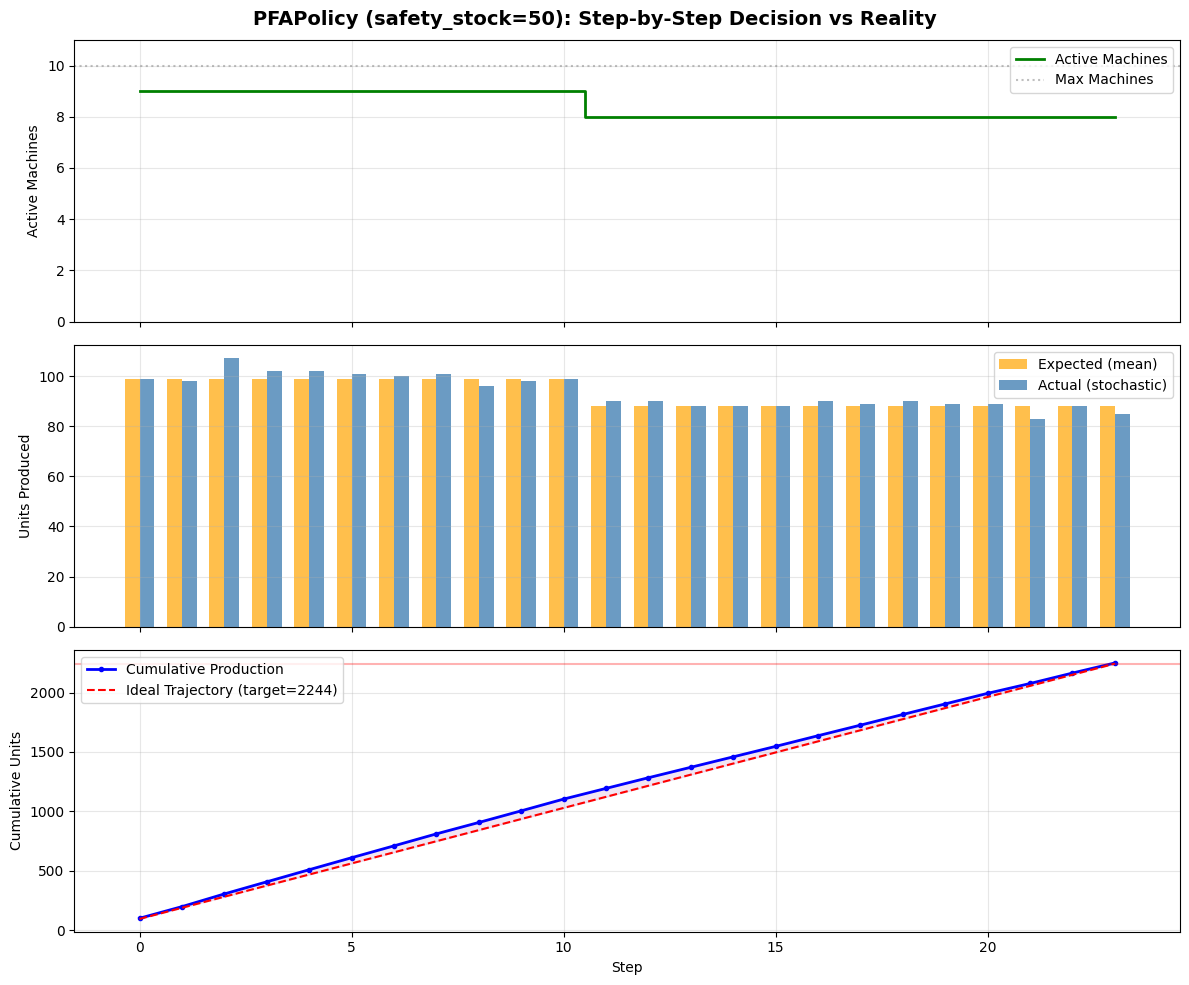

In [4]:
def plot_step_analysis(records, target, policy_name):
    """Plot step-by-step decision vs outcome for a single day."""
    steps = [r['step'] for r in records]
    machines = [r['machines'] for r in records]
    expected = [r['expected'] for r in records]
    actual = [r['actual'] for r in records]
    deviation = [r['deviation'] for r in records]
    cum_prod = [r['cum_prod'] for r in records]

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f'{policy_name}: Step-by-Step Decision vs Reality', fontsize=14, fontweight='bold')

    # Panel 1: Machines activated
    ax = axes[0]
    ax.step(steps, machines, where='mid', color='green', linewidth=2, label='Active Machines')
    ax.axhline(y=model.config.total_machines, color='gray', linestyle=':', alpha=0.5, label='Max Machines')
    ax.set_ylabel('Active Machines')
    ax.legend(loc='upper right')
    ax.set_ylim(0, model.config.total_machines + 1)
    ax.grid(True, alpha=0.3)

    # Panel 2: Expected vs Actual production
    ax = axes[1]
    bar_width = 0.35
    ax.bar([s - bar_width/2 for s in steps], expected, bar_width, color='orange', alpha=0.7, label='Expected (mean)')
    ax.bar([s + bar_width/2 for s in steps], actual, bar_width, color='steelblue', alpha=0.8, label='Actual (stochastic)')
    ax.set_ylabel('Units Produced')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # Panel 3: Cumulative production vs target
    ax = axes[2]
    ideal_trajectory = [target * (s+1) / len(steps) for s in steps]
    ax.plot(steps, cum_prod, 'b-o', markersize=3, linewidth=2, label='Cumulative Production')
    ax.plot(steps, ideal_trajectory, 'r--', linewidth=1.5, label=f'Ideal Trajectory (target={target})')
    ax.axhline(y=target, color='red', linestyle='-', alpha=0.3)
    ax.fill_between(steps, cum_prod, ideal_trajectory, alpha=0.1, color='purple')
    ax.set_ylabel('Cumulative Units')
    ax.set_xlabel('Step')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_step_analysis(records_pfa, target_pfa, 'PFAPolicy (safety_stock=50)')

## 2. Reactive Behavior: How PFA Adjusts to Deviations

Here we show the **deviation at step t** and the **policy reaction at step t+1**.
The PFAPolicy uses urgency-rate control: if production falls behind, it increases
the machine count in subsequent steps to catch up.

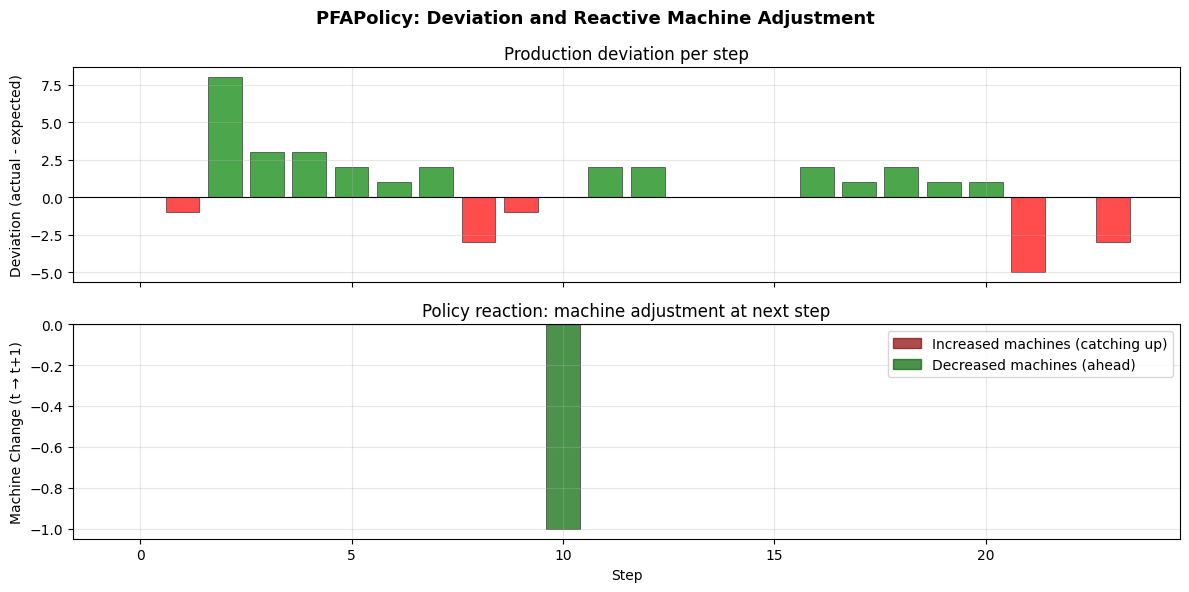

In [5]:
def plot_deviation_reaction(records, policy_name):
    """Show how the policy reacts to deviations from expected output."""
    steps = [r['step'] for r in records]
    deviation = [r['deviation'] for r in records]
    machines = [r['machines'] for r in records]

    # Machine change from step t to step t+1
    machine_change = [machines[i+1] - machines[i] for i in range(len(machines)-1)]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f'{policy_name}: Deviation and Reactive Machine Adjustment', fontsize=13, fontweight='bold')

    # Deviation at each step
    ax = axes[0]
    colors = ['red' if d < 0 else 'green' for d in deviation]
    ax.bar(steps, deviation, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Deviation (actual - expected)')
    ax.set_title('Production deviation per step')
    ax.grid(True, alpha=0.3)

    # Machine adjustment reaction
    ax = axes[1]
    reaction_colors = ['darkred' if c > 0 else 'darkgreen' if c < 0 else 'gray' for c in machine_change]
    ax.bar(steps[:-1], machine_change, color=reaction_colors, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Machine Change (t → t+1)')
    ax.set_xlabel('Step')
    ax.set_title('Policy reaction: machine adjustment at next step')
    ax.grid(True, alpha=0.3)

    # Add legend patches
    patches = [
        mpatches.Patch(color='darkred', alpha=0.7, label='Increased machines (catching up)'),
        mpatches.Patch(color='darkgreen', alpha=0.7, label='Decreased machines (ahead)'),
    ]
    ax.legend(handles=patches, loc='upper right')

    plt.tight_layout()
    plt.show()


plot_deviation_reaction(records_pfa, 'PFAPolicy')

## 3. PFACapacityPolicy — Same Day, Different Strategy

The **PFACapacityPolicy** uses a different approach:
- **Planning**: `target = min(mean_daily_capacity, demand - inventory + buffer)`
- **Control**: Evenly spread remaining gap over remaining steps.

Let's run the same day and compare the reactive behavior.

In [6]:
records_cap, target_cap = run_day_step_by_step(
    pfa_capacity, model, initial_inventory, demand_forecast[0], demand_forecast, day_idx=0, seed=42
)

=== Day 0 | Policy: PFA-Capacity ===
  Inventory: 40, Demand: 2234, Target: 2224
  Step | Machines | Expected | Actual | Deviation | Cum.Prod | Rem.Gap
  -----+----------+----------+--------+-----------+----------+--------
     0 |        9 |     99.0 |     99 |      +0.0 |       99 |    2125
     1 |        9 |     99.0 |     98 |      -1.0 |      197 |    2027
     2 |        9 |     99.0 |    107 |      +8.0 |      304 |    1920
     3 |        9 |     99.0 |    102 |      +3.0 |      406 |    1818
     4 |        9 |     99.0 |    102 |      +3.0 |      508 |    1716
     5 |        9 |     99.0 |    101 |      +2.0 |      609 |    1615
     6 |        9 |     99.0 |    100 |      +1.0 |      709 |    1515
     7 |        9 |     99.0 |    101 |      +2.0 |      810 |    1414
     8 |        9 |     99.0 |     96 |      -3.0 |      906 |    1318
     9 |        8 |     88.0 |     87 |      -1.0 |      993 |    1231
    10 |        8 |     88.0 |     87 |      -1.0 |     1080 |    1

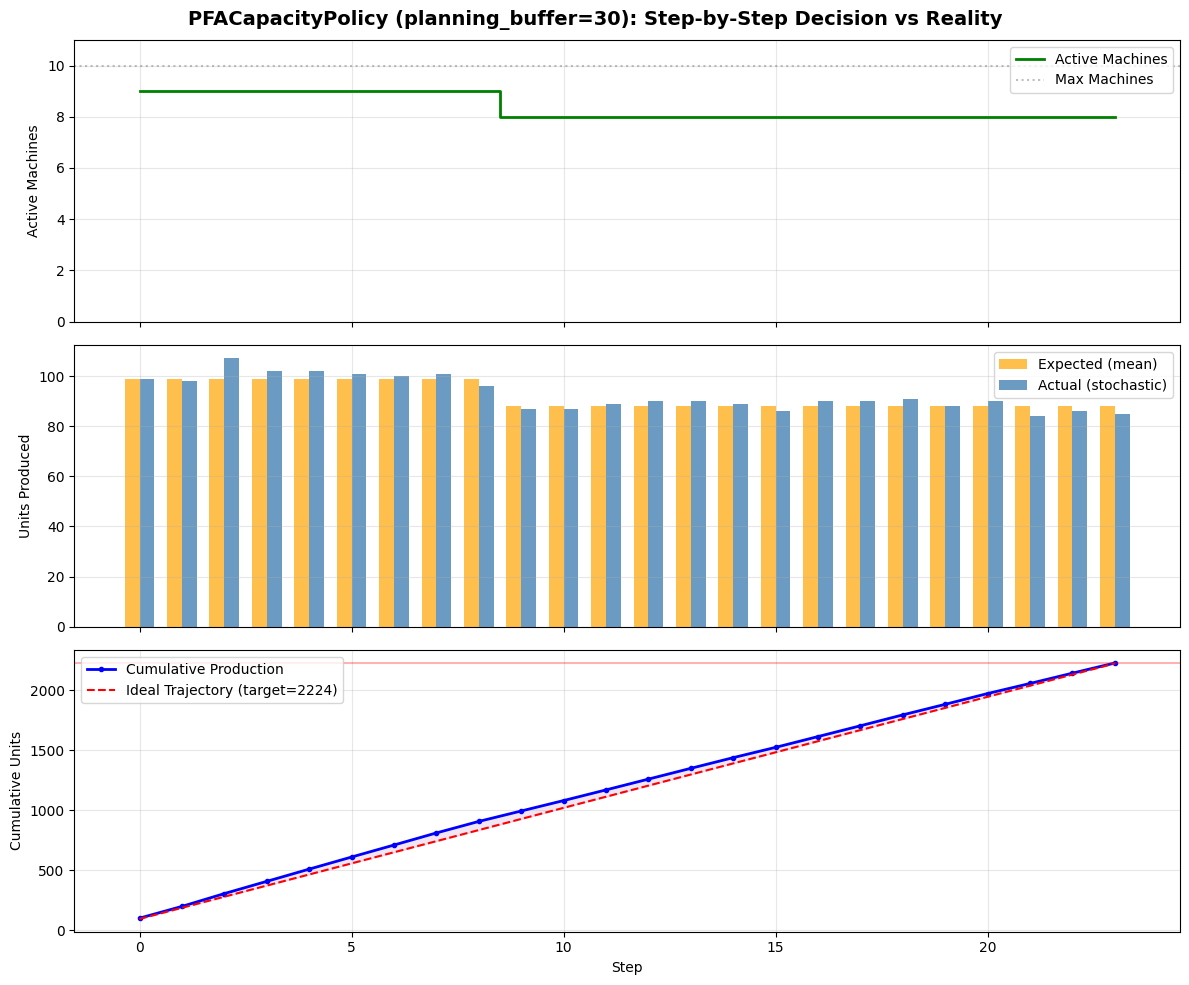

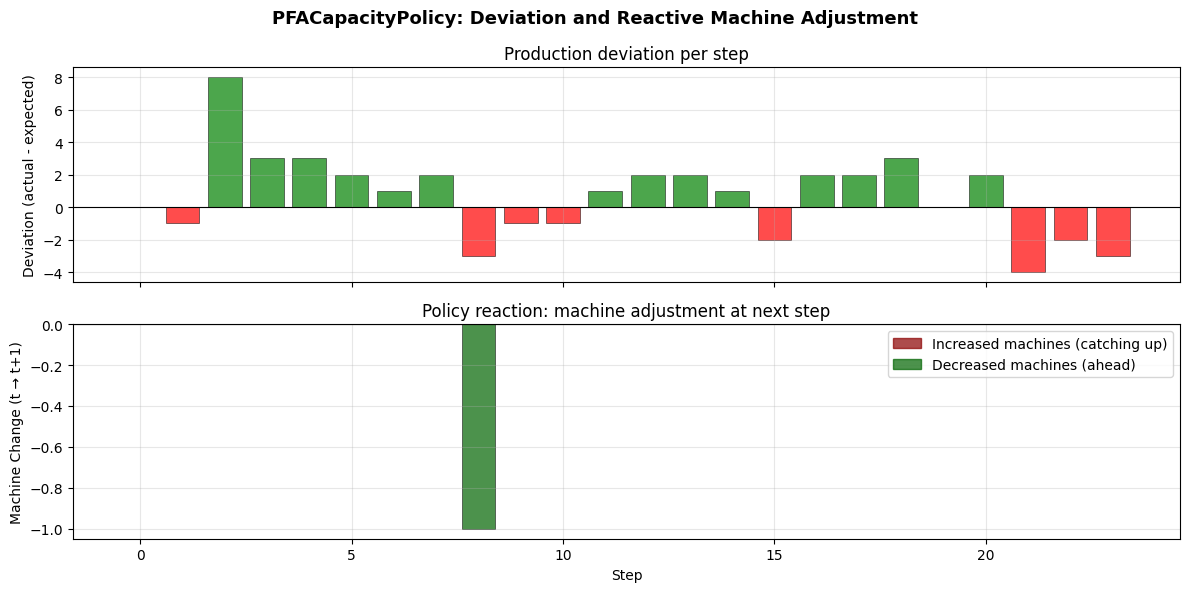

In [7]:
plot_step_analysis(records_cap, target_cap, 'PFACapacityPolicy (planning_buffer=30)')
plot_deviation_reaction(records_cap, 'PFACapacityPolicy')

## 4. Side-by-Side Comparison: Both PFA Policies

Compare how both PFA variants handle the same stochastic realization.

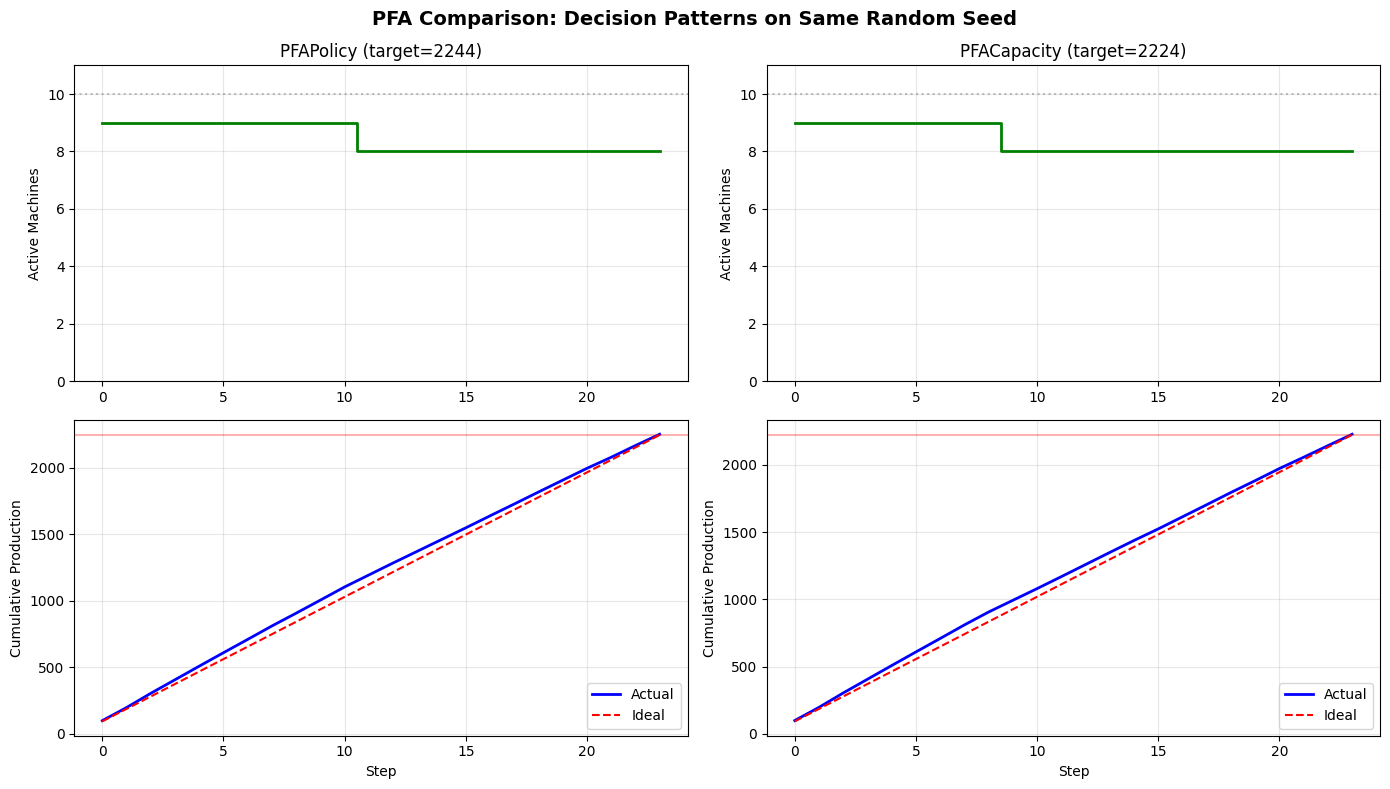

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('PFA Comparison: Decision Patterns on Same Random Seed', fontsize=14, fontweight='bold')

for col, (records, target, name) in enumerate([
    (records_pfa, target_pfa, f'PFAPolicy (target={target_pfa})'),
    (records_cap, target_cap, f'PFACapacity (target={target_cap})'),
]):
    steps = [r['step'] for r in records]
    machines = [r['machines'] for r in records]
    cum_prod = [r['cum_prod'] for r in records]
    deviation = [r['deviation'] for r in records]

    # Top: machines over time
    ax = axes[0, col]
    ax.step(steps, machines, where='mid', color='green', linewidth=2)
    ax.set_title(name)
    ax.set_ylabel('Active Machines')
    ax.set_ylim(0, model.config.total_machines + 1)
    ax.axhline(model.config.total_machines, color='gray', linestyle=':', alpha=0.5)
    ax.grid(True, alpha=0.3)

    # Bottom: cumulative production vs target
    ax = axes[1, col]
    ideal = [target * (s+1) / len(steps) for s in steps]
    ax.plot(steps, cum_prod, 'b-', linewidth=2, label='Actual')
    ax.plot(steps, ideal, 'r--', linewidth=1.5, label='Ideal')
    ax.axhline(target, color='red', alpha=0.3)
    ax.set_ylabel('Cumulative Production')
    ax.set_xlabel('Step')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multi-Day Trajectory: Accumulating Effects of Reactive Decisions

Over multiple days, the PFA policies' reactions compound. Let's trace
inventory, shortage, and machine usage across the full horizon.

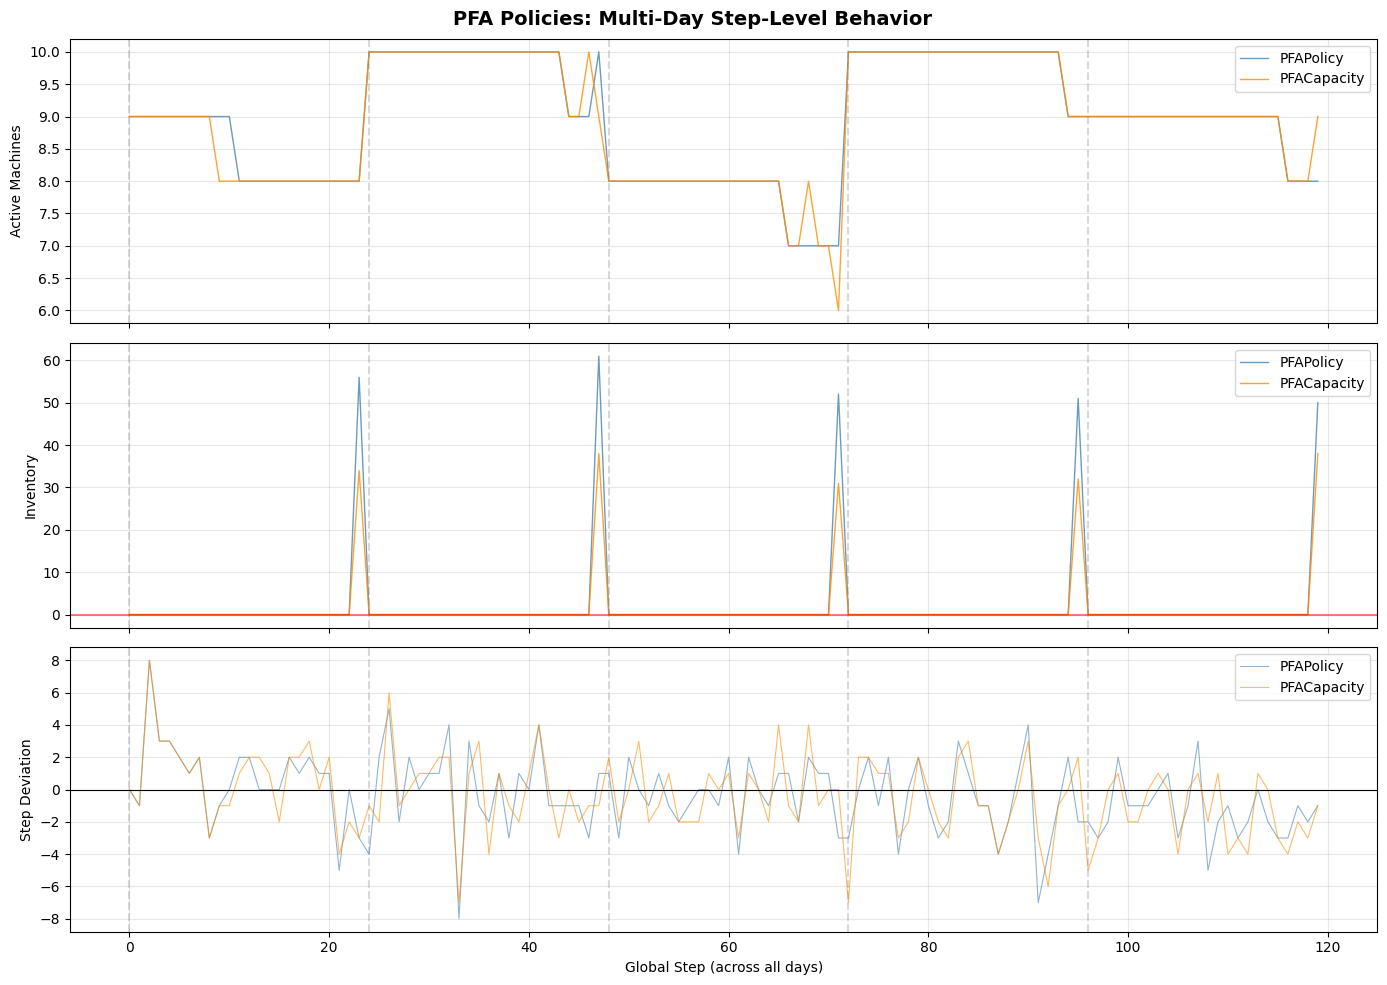

In [9]:
def run_full_episode_detailed(policy, model, initial_inventory, demand_forecast, seed):
    """Run full episode and collect per-step details across all days."""
    rng = random.Random(seed)
    inventory = initial_inventory
    all_records = []
    day_boundaries = []
    global_step = 0

    for day_idx, demand_today in enumerate(demand_forecast):
        planning_state = PlanningState(
            inventory=inventory,
            current_day_index=day_idx,
            demand_today=demand_today,
            forecast_demand=demand_forecast[day_idx:],
        )
        target = max(0, policy.plan_production(planning_state, model))
        day_boundaries.append((global_step, target, demand_today))

        execution_state = ExecutionState(
            inventory=inventory,
            remaining_demand=demand_today,
            remaining_time_steps=model.config.steps_per_day,
            cumulative_production=0,
            production_target=target,
        )

        for step_idx in range(model.config.steps_per_day):
            active_machines = policy.control_machines(execution_state, model, rng)
            step_result = model.execute_step(execution_state, active_machines, rng)
            expected = active_machines * model.config.mean_output_per_machine

            all_records.append({
                'global_step': global_step,
                'day': day_idx,
                'step': step_idx,
                'machines': active_machines,
                'expected': expected,
                'actual': step_result.produced_units,
                'deviation': step_result.produced_units - expected,
                'inventory': step_result.ending_inventory,
                'remaining_demand': step_result.remaining_demand,
            })

            cum_prod = execution_state.cumulative_production + step_result.produced_units
            execution_state = ExecutionState(
                inventory=step_result.ending_inventory,
                remaining_demand=step_result.remaining_demand,
                remaining_time_steps=model.config.steps_per_day - step_idx - 1,
                cumulative_production=cum_prod,
                production_target=target,
            )
            global_step += 1

        inventory = execution_state.inventory

    return all_records, day_boundaries


records_pfa_full, bounds_pfa = run_full_episode_detailed(pfa_basic, model, initial_inventory, demand_forecast, seed=42)
records_cap_full, bounds_cap = run_full_episode_detailed(pfa_capacity, model, initial_inventory, demand_forecast, seed=42)

# Plot multi-day comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('PFA Policies: Multi-Day Step-Level Behavior', fontsize=14, fontweight='bold')

for records, label, color in [
    (records_pfa_full, 'PFAPolicy', 'steelblue'),
    (records_cap_full, 'PFACapacity', 'darkorange'),
]:
    gs = [r['global_step'] for r in records]
    axes[0].plot(gs, [r['machines'] for r in records], linewidth=1, alpha=0.8, label=label, color=color)
    axes[1].plot(gs, [r['inventory'] for r in records], linewidth=1, alpha=0.8, label=label, color=color)
    axes[2].plot(gs, [r['deviation'] for r in records], linewidth=0.8, alpha=0.6, label=label, color=color)

# Day boundaries
for gs, target, demand in bounds_pfa:
    for ax in axes:
        ax.axvline(gs, color='gray', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Active Machines')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_ylabel('Inventory')
axes[1].axhline(0, color='red', linestyle='-', alpha=0.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].set_ylabel('Step Deviation')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Global Step (across all days)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Key Insights: PFA Policies

| Aspect | PFAPolicy | PFACapacityPolicy |
|--------|-----------|-------------------|
| Planning | demand + safety_stock - inventory | min(capacity, demand - inventory + buffer) |
| Control | Urgency rate: remaining gap / remaining time | Even spread: gap / remaining steps |
| Reactivity | High — rapidly adjusts machines when behind | Moderate — smoothly adjusts |
| Risk | May over-produce if ahead early | May under-produce if capacity-limited |

Both are **pure state-to-action mappings** — no optimization or lookahead is involved.
The stochastic outcome at step $t$ directly affects the decision at step $t+1$
through the updated `execution_state` (cumulative production and remaining gap).